___

<a href='https://sites.google.com/fat.uerj.br/livia'> <img src='../figures/capa2.png' /></a>
___


# Análise do componente principal (PCA)

Vamos discutir o PCA! Como este não é exatamente um algoritmo de aprendizado de máquina completo, mas sim um algoritmo de aprendizado não supervisionado, teremos apenas uma pequena discussão sobre esse tópico, mas nenhum projeto de aprendizado de máquina completo (embora passemos pelo conjunto de câncer com o PCA).

## Revisão PCA

Lembre-se de que o PCA é apenas uma transformação de seus dados e tenta descobrir quais recursos explicam a maior variação em seus dados.

PCA é uma técnica usada para reduzir a dimensionalidade de um conjunto de dados. Ele funciona identificando as direções de variação máxima nos dados e criando novos "componentes principais" que capturam o máximo possível da variação. Esses novos componentes principais são combinações lineares dos recursos originais e não estão correlacionados entre si.

Os passos básicos para realizar o PCA são os seguintes:

- Padronize os dados: o PCA é sensível à escala das feições, por isso é importante padronizar os dados subtraindo a média e dividindo pelo desvio padrão de cada feição.

- Calcule a matriz de covariância: A matriz de covariância é uma matriz quadrada que contém as covariâncias pareadas entre todos os recursos.

- Calcule os autovetores e autovalores: Os autovetores são as direções de variação máxima nos dados e os autovalores são as variações ao longo dessas direções. Os autovetores são os principais componentes dos dados.

- Escolha os componentes principais: Depois de ter os autovetores, você pode selecionar os componentes principais escolhendo os autovetores com os autovalores mais altos. Esses autovetores representam as direções de variância máxima nos dados.

- Transforme os dados: Para reduzir a dimensionalidade dos dados, você pode transformar os dados originais no novo espaço definido pelos componentes principais. Isso é feito multiplicando os dados originais pela matriz de componentes principais.

O PCA é frequentemente usado como uma etapa de pré-processamento para outros algoritmos de aprendizado de máquina, como análise discriminante linear ou para visualizar dados de alta dimensão.
Também ajuda a identificar padrões nos dados, removendo multicolinearidade, removendo ruído e outras transformações de dados.

Por exemplo:

<img src='../figures/PCA.png' />

## Bibliotecas

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

## Os dados

Vamos trabalhar com o conjunto de dados de câncer novamente, pois tinha tantos recursos.

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
cancer = load_breast_cancer()

In [4]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [25]:
df = pd.DataFrame(cancer['data'],columns=cancer['feature_names'])
#(['DESCR', 'data', 'feature_names', 'target_names', 'target'])

In [18]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
print(df['mean radius'].mean())
print(df['mean radius'].std())

14.127291739894552
3.5240488262120775


<Axes: >

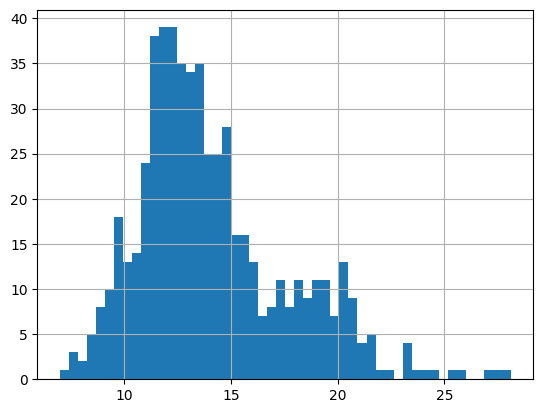

In [27]:
df['mean radius'].hist(bins=50)

In [9]:
df.shape

(569, 30)

## Visualização de PCA

Como notamos antes, é difícil visualizar dados de alta dimensão, podemos usar o PCA para encontrar os dois primeiros componentes principais e visualizar os dados nesse novo espaço bidimensional, com um único gráfico de dispersão. Antes de fazer isso, no entanto, precisaremos dimensionar nossos dados para que cada recurso tenha uma variância de unidade única.

In [11]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
scaler.fit(df)


StandardScaler()

In [21]:
scaled_data = scaler.transform(df)
#scaled_data = scaler.fit_transform(df)

In [15]:
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

In [28]:
df = pd.DataFrame(scaled_data,columns=cancer['feature_names'])

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [29]:
print(df['mean radius'].mean())
print(df['mean radius'].std())

-3.153111437248248e-15
1.000879894582902


<Axes: >

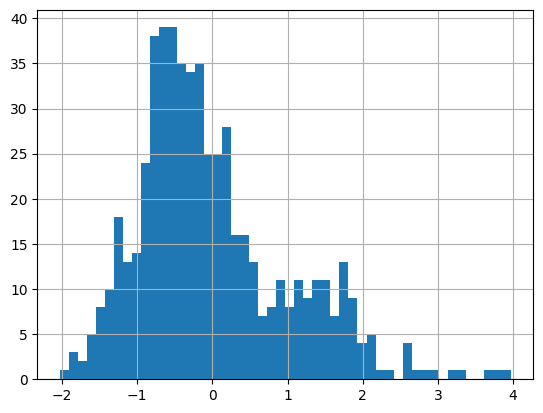

In [30]:
df['mean radius'].hist(bins=50)

PCA com Scikit Learn usa um processo muito semelhante a outras funções de pré-processamento que vêm com o SciKit Learn. Instanciamos um objeto PCA, encontramos os componentes principais usando o método fit, em seguida, aplicamos a rotação e a redução de dimensionalidade chamando transform().
Também podemos especificar quantos componentes queremos manter ao criar o objeto PCA.

In [31]:
from sklearn.decomposition import PCA

In [55]:
pca = PCA(n_components=5)

In [56]:
pca.fit(scaled_data)
# pca.fit_transform(scaled_data)

PCA(n_components=5)

Agora podemos transformar esses dados em seus dois primeiros componentes principais.

In [57]:
x_pca = pca.transform(scaled_data)

In [35]:
scaled_data.shape

(569, 30)

In [58]:
x_pca.shape

(569, 5)

Perfeito! Agora temos os dois primeiros componentes principais para cada ponto de dados reduzindo a dimensionalidade de 30 para apenas 2! Vamos plotar essas duas dimensões!

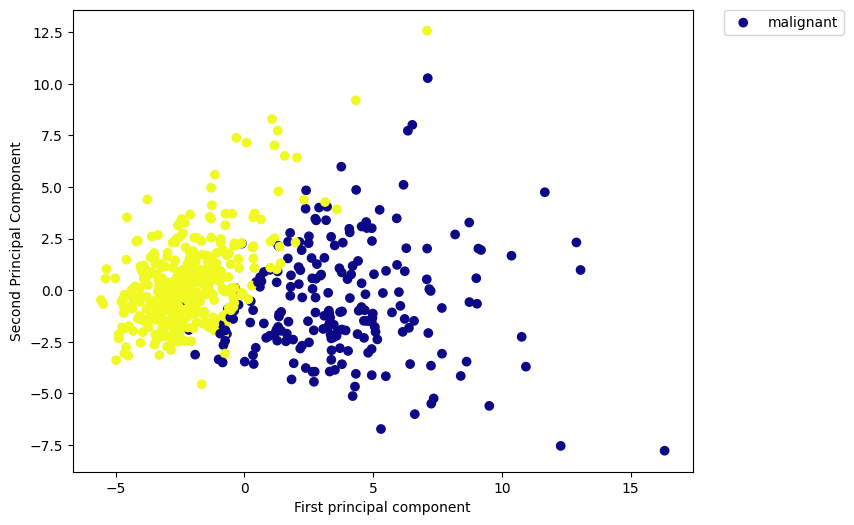

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=cancer['target'],cmap='plasma')
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')
plt.legend(cancer['target_names'],bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

Obviamente, usando esses dois componentes, podemos separar essas duas classes.

## Interpretando os componentes

Infelizmente, com esse grande poder de redução de dimensionalidade, vem o custo de ser capaz de entender facilmente o que esses componentes representam.

Os componentes correspondem a combinações dos recursos originais, os componentes em si são armazenados como um atributo do objeto PCA ajustado:

In [60]:
pca.components_

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947],
       [-0.00853124,  0.0645499 , -0.00931422,  0.02869953, -0.1042919 ,
        -0.07409157,  0.00273384, -0.02556354, -0

Neste matriz de array do Numpy, cada linha representa um componente principal, e cada coluna se refere aos recursos originais. Podemos visualizar essa relação com um mapa de calor:

In [61]:
df_comp = pd.DataFrame(pca.components_,columns=cancer['feature_names'])

<Axes: >

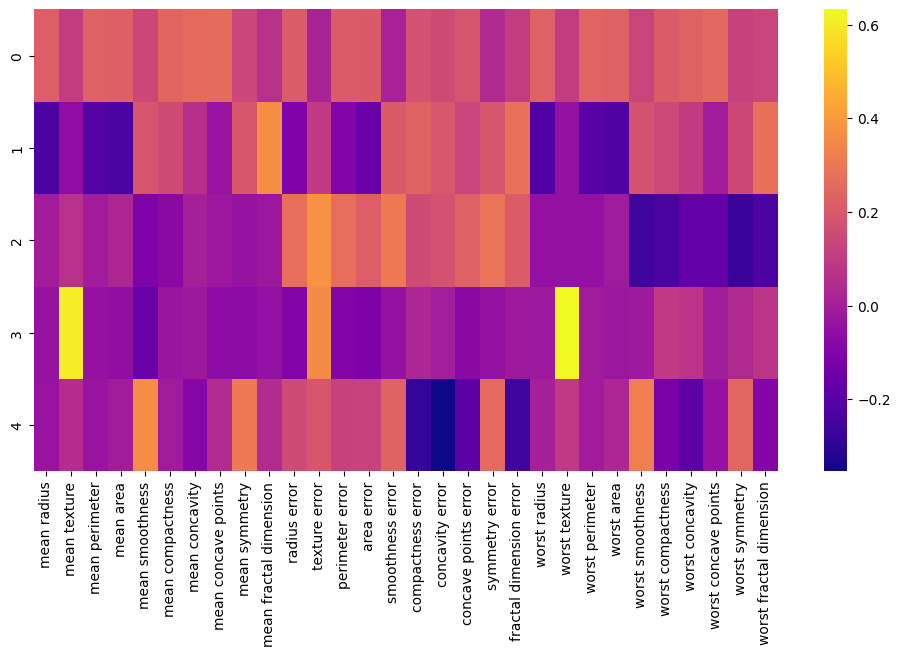

In [62]:
plt.figure(figsize=(12,6))
sns.heatmap(df_comp,cmap='plasma',)

Essa mapa de calor e a barra de cores basicamente representam a correlação entre os vários recursos e o próprio componente principal.

Outro método é um `screeplot` para visualizar a importância relativa dos componentes principais (o nome deriva da semelhança do gráfico com uma inclinação de seixos; aqui, o eixo y é o autovalor).



Text(0.5, 0, 'Component')

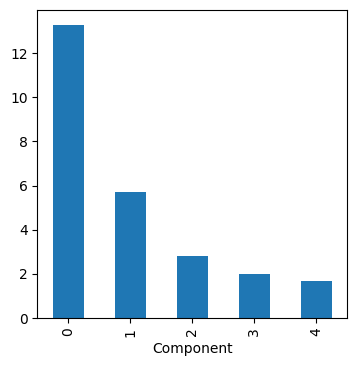

In [63]:
explained_variance = pd.DataFrame(pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

In [64]:
explained_variance_ratio = pca.explained_variance_ratio_
total_explained = explained_variance_ratio.sum() * 100
print(f"Os dois primeiros componentes principais explicam {total_explained:.2f}% da variância total dos dados.")

Os dois primeiros componentes principais explicam 84.73% da variância total dos dados.


Podemos ter um grafico parecido com o mapa de calor acima para ver a influência de cada feature em cada componente principal:

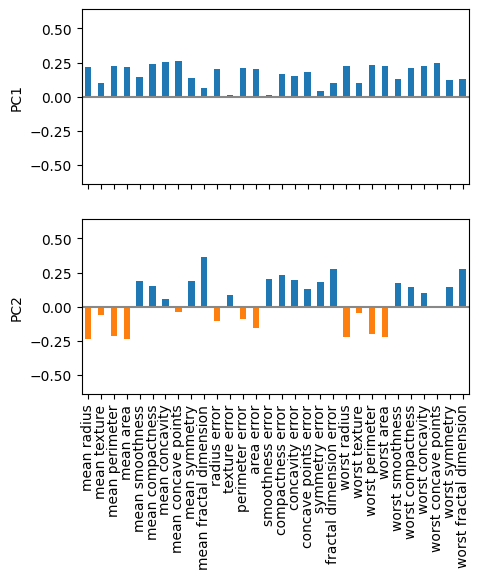

In [65]:
loadings = pd.DataFrame(pca.components_[0:5, :], columns=df.columns)
maxPC = 1.01 * np.max(np.max(np.abs(loadings.loc[0:5, :])))
f, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}')
    ax.set_ylim(-maxPC, maxPC)

## Conclusão

Espero que essas informações sejam úteis para você ao lidar com dados de alta dimensão!